In [5]:
import pandas as pd
import geopandas as gpd
import os
import json

import sys
sys.path.append('..')
from helpers import get_county2zone, calculate_intersection

In [2]:
def get_baseline_load_profiles():
    baseline_load_profiles = {}
    hourly_demand_path = "../data/baseline_load_profiles/processed"
    for fname in os.listdir(hourly_demand_path):
        fpath = os.path.join(hourly_demand_path, fname)
        if os.path.isdir(fpath):
            continue
        df = pd.read_csv(fpath, parse_dates=["timestamp"], index_col="timestamp")
        eia_code = fname.replace('.csv', '')
        baseline_load_profiles[eia_code] = df

    return baseline_load_profiles

In [4]:
baseline_load_profiles = get_baseline_load_profiles()
eia_code_total_load_map = {}
for eia_code, df in baseline_load_profiles.items():
    eia_code_total_load_map[eia_code] = df.loc[df.index.year == 2023]['value'].sum()

In [6]:
county2zone = get_county2zone(2023)
county2zone['state_fips'] = county2zone['FIPS'].str.split('p').str[1].str[:2]

In [7]:
county_geo = gpd.read_file("../data/shapefiles/US_COUNTY_2022")
eia_zones = gpd.read_file('../data/shapefiles/bas_and_subbas')

In [8]:
ct_pops = pd.read_csv('../data/DECENNIALDHC2020.P1_2025-08-20T004859/DECENNIALDHC2020.P1-Data.csv')
ct_pops['GEOID'] = ct_pops['GEO_ID'].str.split('US').str[1]
ct_pops = ct_pops.rename(columns={'P1_001N': 'population'})
ct_pops = ct_pops[['GEOID', 'population']]

In [9]:
all_state_cts = []
for state_fips in county2zone['state_fips'].unique().tolist():
    if state_fips == '09':
        continue

    print(f"Reading census tracts for state {state_fips}...", end="")

    state_cts = (
        gpd.read_file(f'../data/shapefiles/census_tracts/tl_2022_{state_fips}_tract')
        .to_crs(eia_zones.crs)
    )
    assert len(state_cts.merge(ct_pops, on='GEOID')) == len(state_cts)

    all_state_cts.append(state_cts)
    print(" done")

Reading census tracts for state 53... done
Reading census tracts for state 41... done
Reading census tracts for state 06... done
Reading census tracts for state 32... done
Reading census tracts for state 16... done
Reading census tracts for state 30... done
Reading census tracts for state 56... done
Reading census tracts for state 49... done
Reading census tracts for state 04... done
Reading census tracts for state 35... done
Reading census tracts for state 46... done
Reading census tracts for state 08... done
Reading census tracts for state 38... done
Reading census tracts for state 31... done
Reading census tracts for state 27... done
Reading census tracts for state 19... done
Reading census tracts for state 55... done
Reading census tracts for state 48... done
Reading census tracts for state 40... done
Reading census tracts for state 20... done
Reading census tracts for state 29... done
Reading census tracts for state 05... done
Reading census tracts for state 22... done
Reading cen

In [10]:
state_cts = pd.concat(all_state_cts, ignore_index=True)
state_cts = state_cts.merge(ct_pops, on='GEOID')
state_cts['population_density'] = state_cts['population'].astype(float) / state_cts['ALAND']

zone_ct_intersects = calculate_intersection(eia_zones, state_cts, ['EIAcode', 'GEOID'])

In [11]:
county_population_map = dict(zip(county2zone['FIPS'], county2zone['population']))

In [12]:
zone_ct_intersects = zone_ct_intersects.loc[zone_ct_intersects.EIAcode != '4004'].copy()
zone_ct_intersects['FIPS'] = (
    'p' + zone_ct_intersects['STATEFP'].astype(str) + zone_ct_intersects['COUNTYFP'].astype(str)
)
zone_ct_intersects['county_population'] = zone_ct_intersects['FIPS'].map(county_population_map)

zone_ct_intersects['population'] = (
    zone_ct_intersects['population_density'] * zone_ct_intersects['geometry'].area
)
zone_ct_intersects['population'] = (
    zone_ct_intersects['population']
    / zone_ct_intersects.groupby('FIPS')['population'].transform('sum')
    * zone_ct_intersects['county_population']
)

In [13]:
zone_ct_intersects['percent_of_zone_population'] = (
    zone_ct_intersects['population'] / zone_ct_intersects.groupby('EIAcode')['population'].transform('sum')
)
zone_ct_intersects['zonal_load'] = zone_ct_intersects['EIAcode'].map(eia_code_total_load_map)
zone_ct_intersects['load'] = zone_ct_intersects['zonal_load'] * zone_ct_intersects['percent_of_zone_population']

In [22]:
ct_load = zone_ct_intersects[['EIAcode', 'GEOID', 'FIPS', 'load']]

In [27]:
county_load = zone_ct_intersects.groupby(['FIPS', 'EIAcode'], as_index=False)['load'].sum()
county_load = county_load.merge(county2zone[['FIPS', 'state']])
county_load['percent_of_county_load_served'] = (
    county_load['load'] / county_load.groupby('FIPS')['load'].transform('sum')
)
county_load['percent_of_county_load_served'] = county_load['percent_of_county_load_served'].round(3)
county_load = county_load.loc[county_load['percent_of_county_load_served'] > 0].copy().reset_index(drop=True)

In [17]:
state_fips = '31'
state_cts = (
    gpd.read_file(f'../data/shapefiles/census_tracts/tl_2022_{state_fips}_tract')
    .to_crs(county_geo.crs)
)

In [18]:
def remove_points_and_lines(df, dissolve_cols=None):
    df = df.explode()
    if dissolve_cols:
        df = (
            df.loc[~df.geometry.type.isin(['Point', 'LineString'])]
            .dissolve(dissolve_cols)
            .reset_index()
        )
    else:
        df = (
            df.loc[~df.geometry.type.isin(['Point', 'LineString'])]
            .dissolve()
            .reset_index()
        )

    return df

def calculate_intersection(df1, df2, dissolve_cols):
    df_intersect = gpd.overlay(
        df1,
        df2,
        how='intersection',
        keep_geom_type=False
    )
    df_intersect = remove_points_and_lines(df_intersect, dissolve_cols)

    return df_intersect

In [19]:
inter = calculate_intersection(
    eia_zones,
    county_geo,
    ['NAME', 'EIAcode']
)

In [29]:
inter_sub = (
    inter.loc[(
        (inter.rb == 'p31109') & (inter.EIAcode.isin(county_load.loc[county_load.FIPS == 'p31109'].EIAcode))
    )]
    .copy()
    .drop(columns='FIPS')
    .rename(columns={'rb': 'FIPS'})
)
inter_sub_cts = calculate_intersection(
    inter_sub,
    state_cts,
    ['EIAcode', 'GEOID']
)

In [30]:
ct_load['GEOID'] = ct_load['GEOID'].astype(str)

C:\Users\cobika\AppData\Local\Temp\1\ipykernel_39352\1581580498.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ct_load['GEOID'] = ct_load['GEOID'].astype(str)


In [31]:
inter_sub_cts = inter_sub_cts.merge(ct_load, on=['EIAcode', 'GEOID', 'FIPS'])

In [32]:
import matplotlib.pyplot as plt
import contextily as ctx

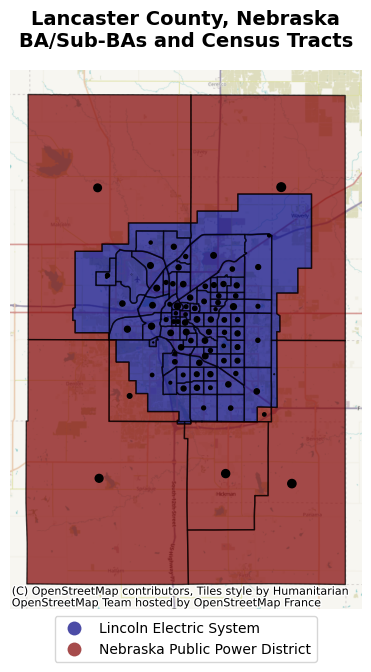

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

gdf = inter_sub_cts.to_crs(epsg=3857)
gdf.plot(
    column='EIAname',
    cmap='jet',
    legend=True,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0),
        'ncol':1
    },
    ax=ax,
    edgecolor='black',
    alpha=0.7
)
gdf.centroid.plot(
    ax=ax,
    color='black',
    markersize=gdf['load'] / gdf['load'].sum() * 1000,
)

ax.set_title('Lancaster County, Nebraska\nBA/Sub-BAs and Census Tracts', fontweight='bold', fontsize=14)
ctx.add_basemap(ax)
ax.set_axis_off()

# plt.show()
plt.savefig('lancaster_county_coverage_with_load.png', dpi=300, bbox_inches='tight')

In [34]:
inter_sub_cts['percentage_of_county_load_served'] = (
    inter_sub_cts['load'] / inter_sub_cts.groupby('FIPS')['load'].transform('sum')
)

In [35]:
inter_sub_cts.groupby('EIAcode')['percentage_of_county_load_served'].sum()

EIAcode
LES     0.814335
NPPD    0.185665
Name: percentage_of_county_load_served, dtype: float64